In [13]:
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from pathlib import Path
MLFLOW_TRACKING_URI = "http://localhost:5002"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

PATH = Path.cwd().parent

print(f"Tracking URI set to: {mlflow.get_tracking_uri()}")



Tracking URI set to: http://localhost:5002


In [10]:
import os

MODEL_NAME = "superconductivity_svr_model"
MODEL_ALIAS = "latest" 


try:
    model_uri = f"models:/{MODEL_NAME}/{MODEL_ALIAS}"
    model = mlflow.sklearn.load_model(model_uri)
    print(f"Successfully loaded: {MODEL_NAME}")
    
   
    if hasattr(model, 'feature_names_in_'):
        print(f"Found {len(model.feature_names_in_)} feature names in model.")
    else:
        print(" Warning: Model doesn't have feature names stored. Use a named DataFrame for predictions.")
        
except Exception as e:
    print(f" Error: {e}")

Successfully loaded: superconductivity_svr_model
Found 81 feature names in model.


In [16]:
test_df =  pd.read_csv(f"{PATH}/data/test_split.csv") 

target_col = 'critical_temp'


X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]


In [ ]:
y_pred = model.predict(X_test)


residuals = y_test - y_pred
    
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
    
print(f"--- Performance Metrics ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.2f} K")
print(f"MAE:      {mae:.2f} K")


--- Performance Metrics ---
R² Score: 0.8566
RMSE:     12.99 K
MAE:      7.49 K


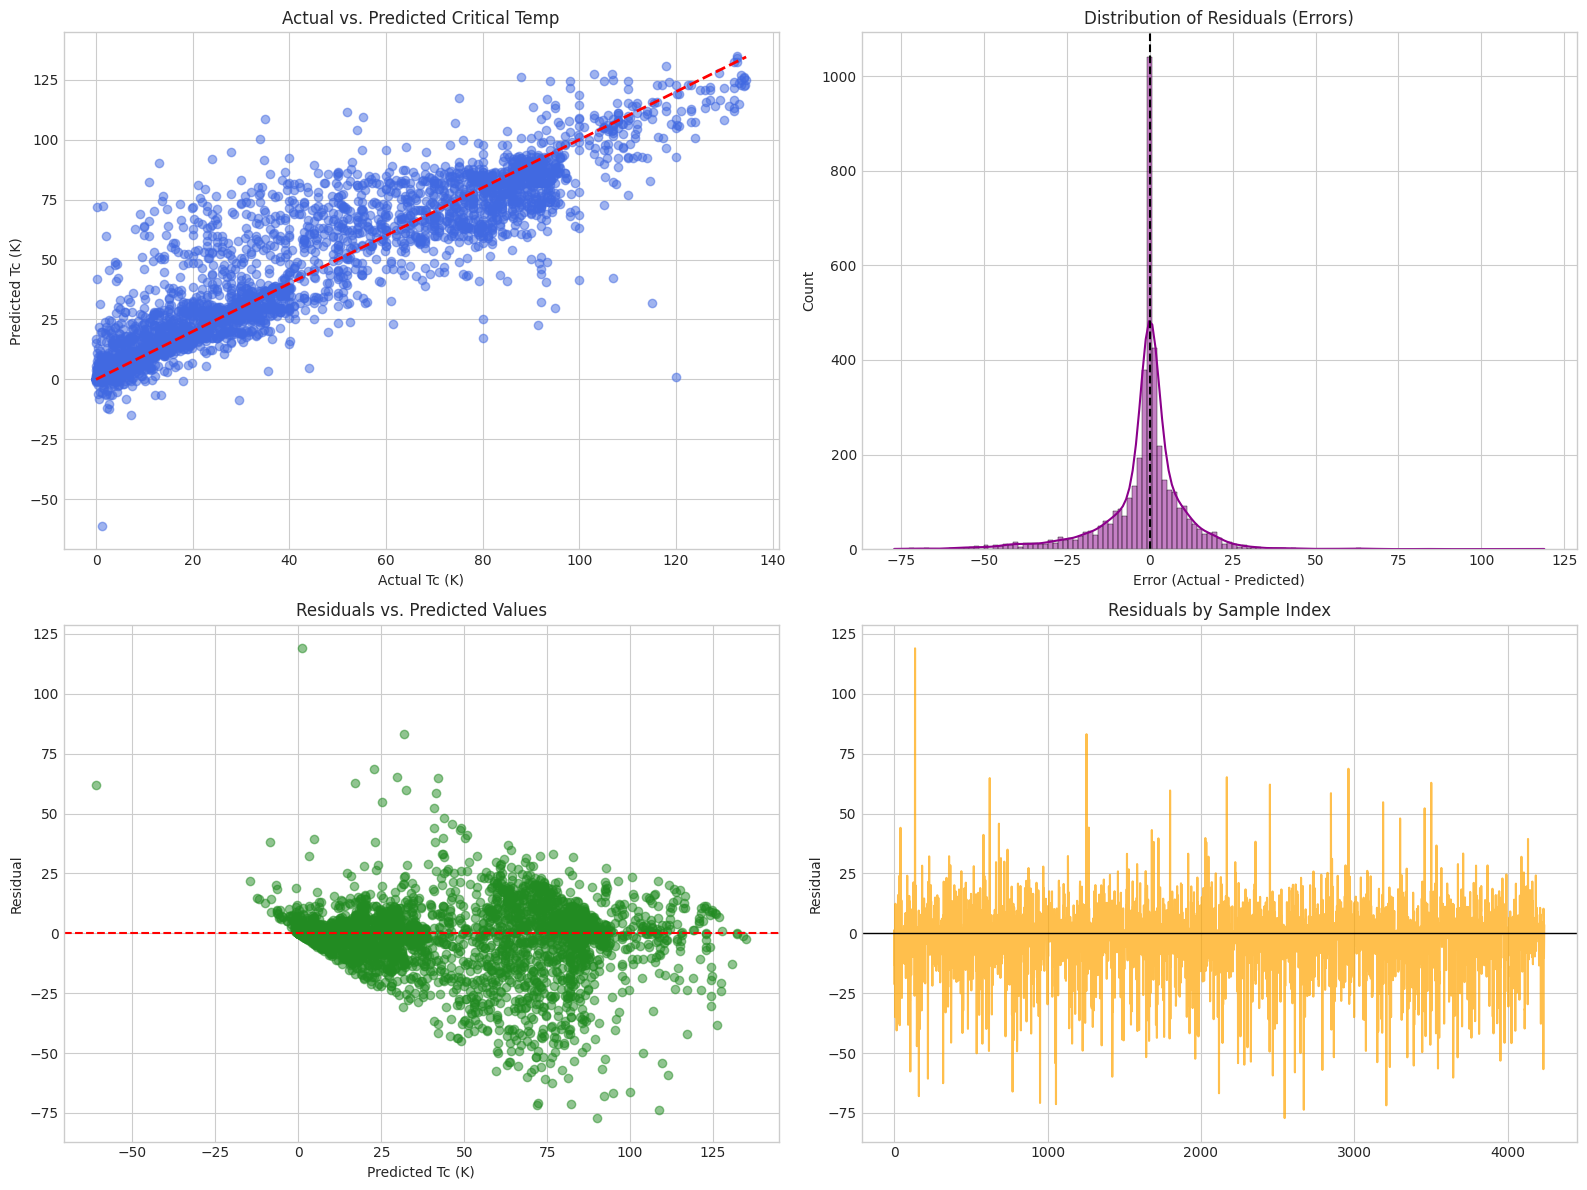

In [19]:
if y_test is not None:
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Actual vs Predicted
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5, color='royalblue')
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
    axes[0, 0].set_title('Actual vs. Predicted Critical Temp')
    axes[0, 0].set_xlabel('Actual Tc (K)')
    axes[0, 0].set_ylabel('Predicted Tc (K)')

    # 2. Residual Distribution (Histogram)
    sns.histplot(residuals, kde=True, ax=axes[0, 1], color='darkmagenta')
    axes[0, 1].axvline(0, color='black', linestyle='--')
    axes[0, 1].set_title('Distribution of Residuals (Errors)')
    axes[0, 1].set_xlabel('Error (Actual - Predicted)')

    # 3. Residuals vs Predicted (Homoscedasticity)
    axes[1, 0].scatter(y_pred, residuals, alpha=0.5, color='forestgreen')
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_title('Residuals vs. Predicted Values')
    axes[1, 0].set_xlabel('Predicted Tc (K)')
    axes[1, 0].set_ylabel('Residual')

    # 4. Error Over Time/Index
    axes[1, 1].plot(residuals.values, alpha=0.7, color='orange')
    axes[1, 1].axhline(0, color='black', lw=1)
    axes[1, 1].set_title('Residuals by Sample Index')
    axes[1, 1].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()

In [ ]:
svr_step = model.named_steps['svr'] 
n_support = len(svr_step.support_)
print(f"Number of Support Vectors: {n_support} out of {len(X_test)} test samples")

Number of Support Vectors: 16738 out of 4240 test samples
